<a href="https://colab.research.google.com/github/rupeshkumar8743/OIBSIP/blob/main/Task3_Car.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

print('All library installed')

All library installed


In [2]:
df = pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.shape

(301, 9)

In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
CompanyName = df['Car_Name'].apply(lambda x : x.split(' ')[0])
df.insert(3,"CompanyName",CompanyName)
df.drop(['Car_Name'],axis=1,inplace=True)
df.head()

,Year,Selling_Price,CompanyName,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,3.35,ritz,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,sx4,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,ciaz,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,wagon,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,swift,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
df.CompanyName.unique()

array(['ritz', 'sx4', 'ciaz', 'wagon', 'swift', 'vitara', 's', 'alto',
       'ertiga', 'dzire', 'ignis', '800', 'baleno', 'omni', 'fortuner',
       'innova', 'corolla', 'etios', 'camry', 'land', 'Royal', 'UM',
       'KTM', 'Bajaj', 'Hyosung', 'Mahindra', 'Honda', 'Yamaha', 'TVS',
       'Hero', 'Activa', 'Suzuki', 'i20', 'grand', 'i10', 'eon', 'xcent',
       'elantra', 'creta', 'verna', 'city', 'brio', 'amaze', 'jazz'],
      dtype=object)

In [7]:
df.CompanyName = df.CompanyName.str.lower()

def replace_name(a,b):
    df.CompanyName.replace(a,b,inplace=True)

replace_name('maxda','mazda')
replace_name('porcshce','porsche')
replace_name('toyouta','toyota')
replace_name('vokswagen','volkswagen')
replace_name('vw','volkswagen')

df.CompanyName.unique()

/tmp/ipykernel_15411/3483460564.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.CompanyName.replace(a,b,inplace=True)


array(['ritz', 'sx4', 'ciaz', 'wagon', 'swift', 'vitara', 's', 'alto',
       'ertiga', 'dzire', 'ignis', '800', 'baleno', 'omni', 'fortuner',
       'innova', 'corolla', 'etios', 'camry', 'land', 'royal', 'um',
       'ktm', 'bajaj', 'hyosung', 'mahindra', 'honda', 'yamaha', 'tvs',
       'hero', 'activa', 'suzuki', 'i20', 'grand', 'i10', 'eon', 'xcent',
       'elantra', 'creta', 'verna', 'city', 'brio', 'amaze', 'jazz'],
      dtype=object)

/tmp/ipykernel_15411/1294116113.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Selling_Price)


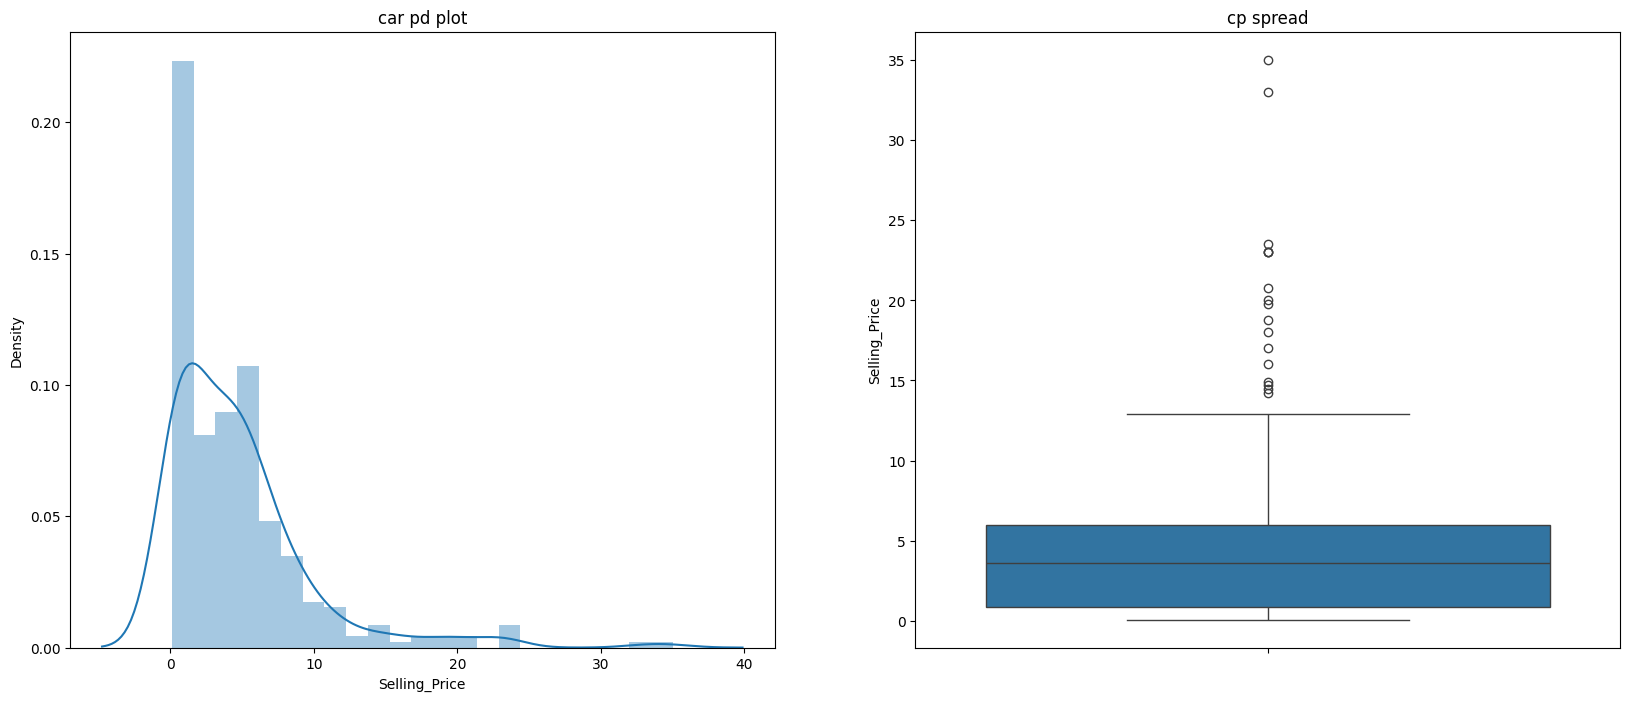

In [8]:
plt.figure(figsize=(20,8))

plt.subplot(1,2,1)
plt.title('car pd plot')
sns.distplot(df.Selling_Price)

plt.subplot(1,2,2)
plt.title('cp spread')
sns.boxplot(y=df.Selling_Price)

plt.show()

/tmp/ipykernel_15411/2247411561.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fuel_Type', data=df, palette="cubehelix")
/tmp/ipykernel_15411/2247411561.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette="cubehelix")


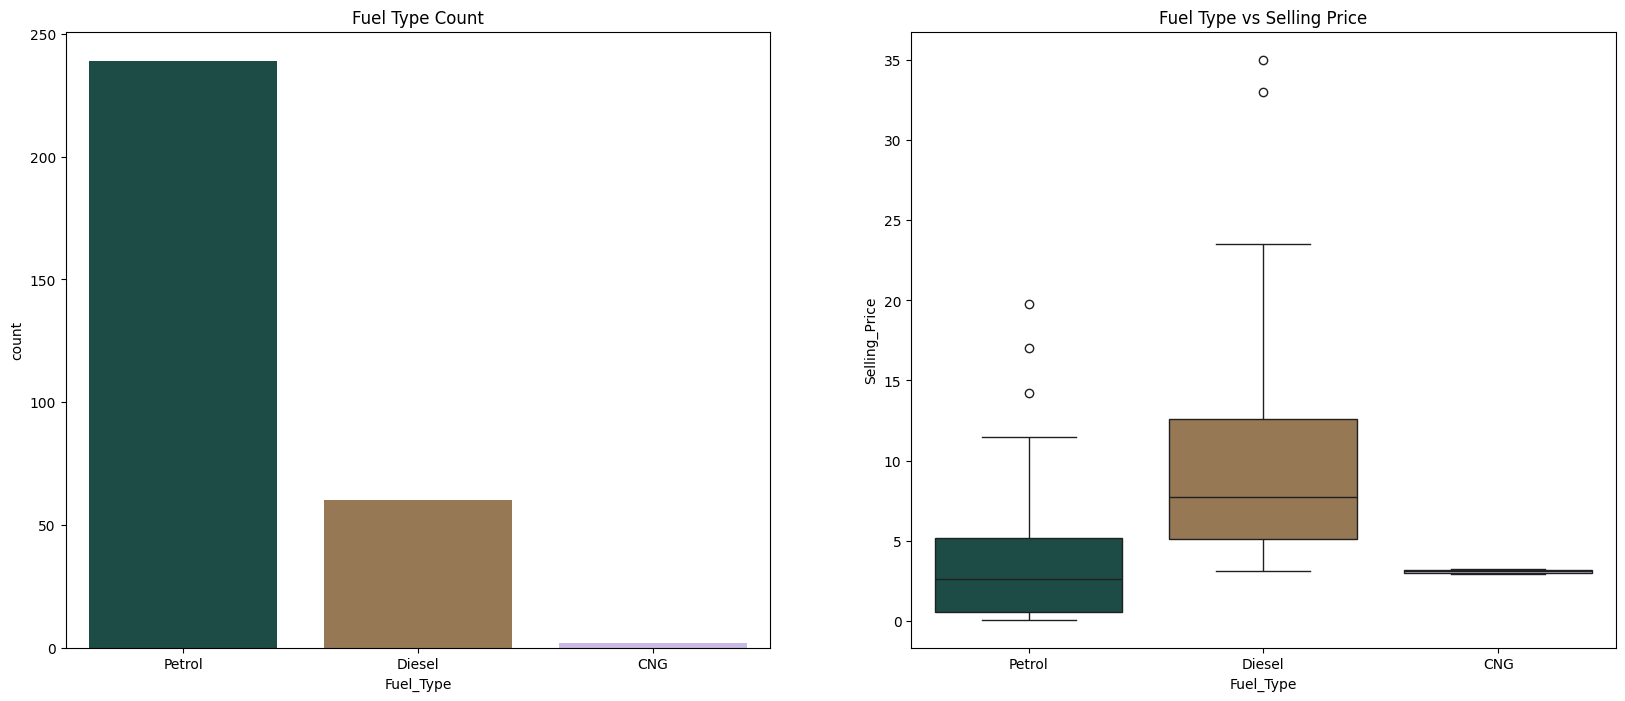

In [9]:
# Plot setup
plt.figure(figsize=(20,8))

# 1. Left Graph: Fuel Type Count (Histogram)
plt.subplot(1,2,1)
plt.title('Fuel Type Count')
# 'x' specify karna zaroori hai naye versions mein
sns.countplot(x='Fuel_Type', data=df, palette="cubehelix")

# 2. Right Graph: Fuel Type vs Selling Price (Boxplot)
plt.subplot(1,2,2)
plt.title('Fuel Type vs Selling Price')
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette="cubehelix")

plt.show()

/tmp/ipykernel_15411/3270556649.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fuel_Type', data=df, palette="Blues_d")
/tmp/ipykernel_15411/3270556649.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette="PuBuGn")


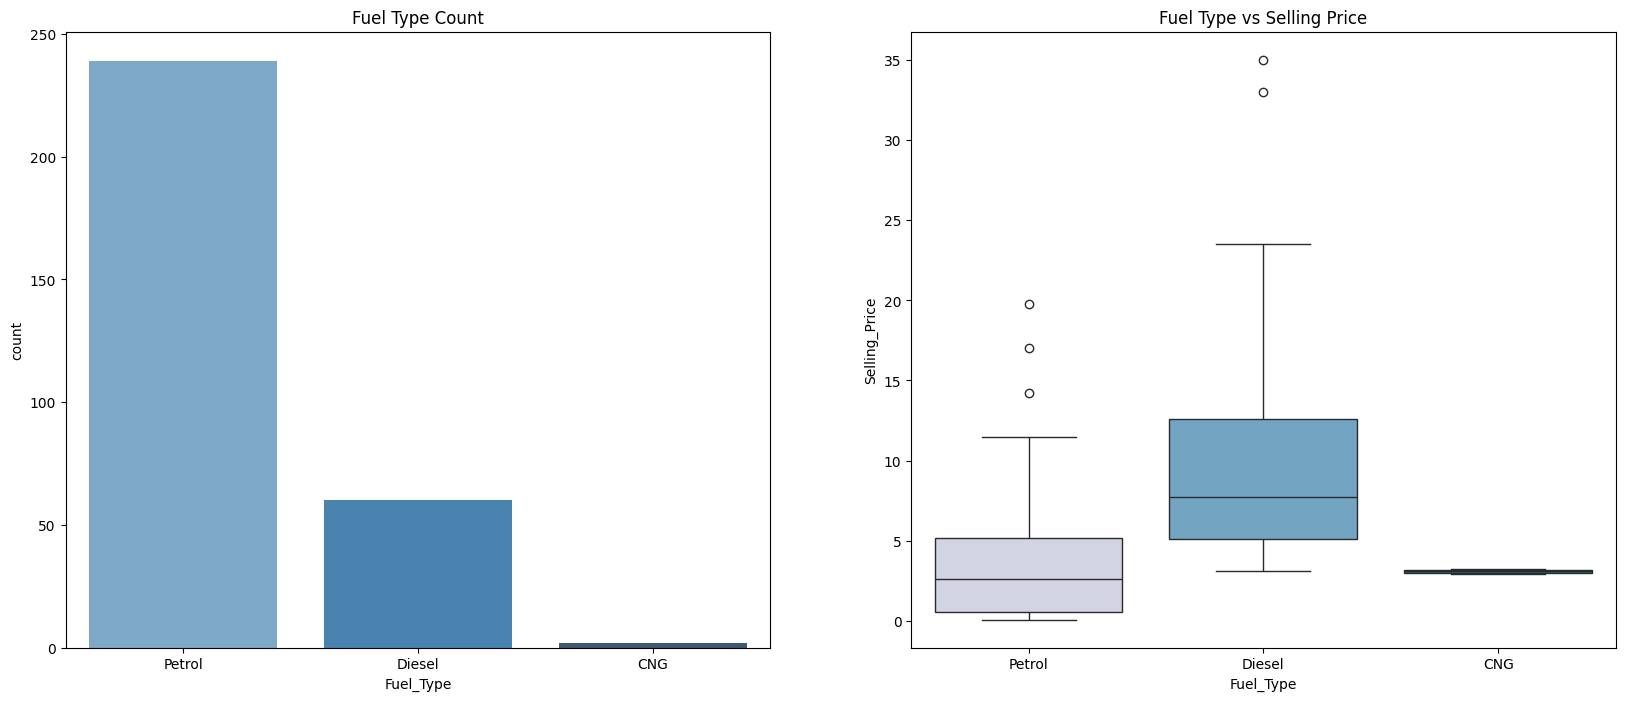

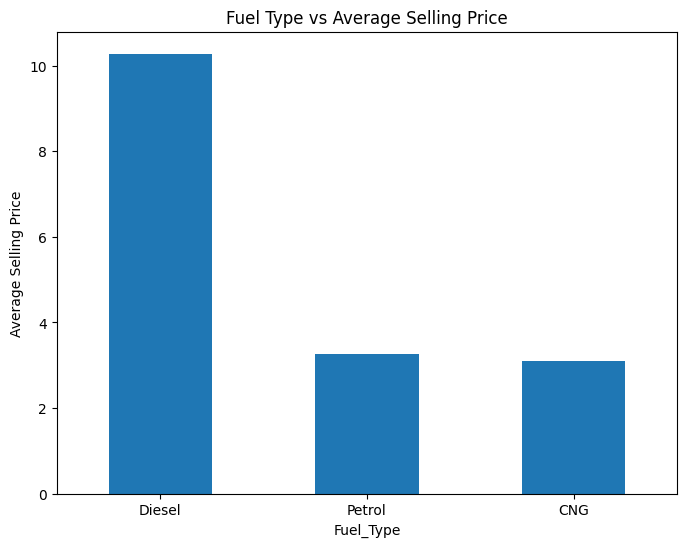

In [10]:
plt.figure(figsize=(20,8))

# Subplot 1: Fuel Type Count
plt.subplot(1,2,1)
plt.title('Fuel Type Count')
sns.countplot(x='Fuel_Type', data=df, palette="Blues_d")

# Subplot 2: Fuel Type vs Price
plt.subplot(1,2,2)
plt.title('Fuel Type vs Selling Price')
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette="PuBuGn")

plt.show()

# 2. Second Figure: Average Price Bar Chart
# Naye variable (df_avg) ka use karein taaki original df kharab na ho
df_avg = df.groupby(['Fuel_Type'])['Selling_Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,6))
df_avg.plot.bar()
plt.title('Fuel Type vs Average Selling Price')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_15411/2142747291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x, data=df, palette="magma")
/tmp/ipykernel_15411/2142747291.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=x, y='Selling_Price', data=df, palette="magma")
/tmp/ipykernel_15411/2142747291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x, data=df, palette="magma")
/tmp/ipykernel_15411/2142747291.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and

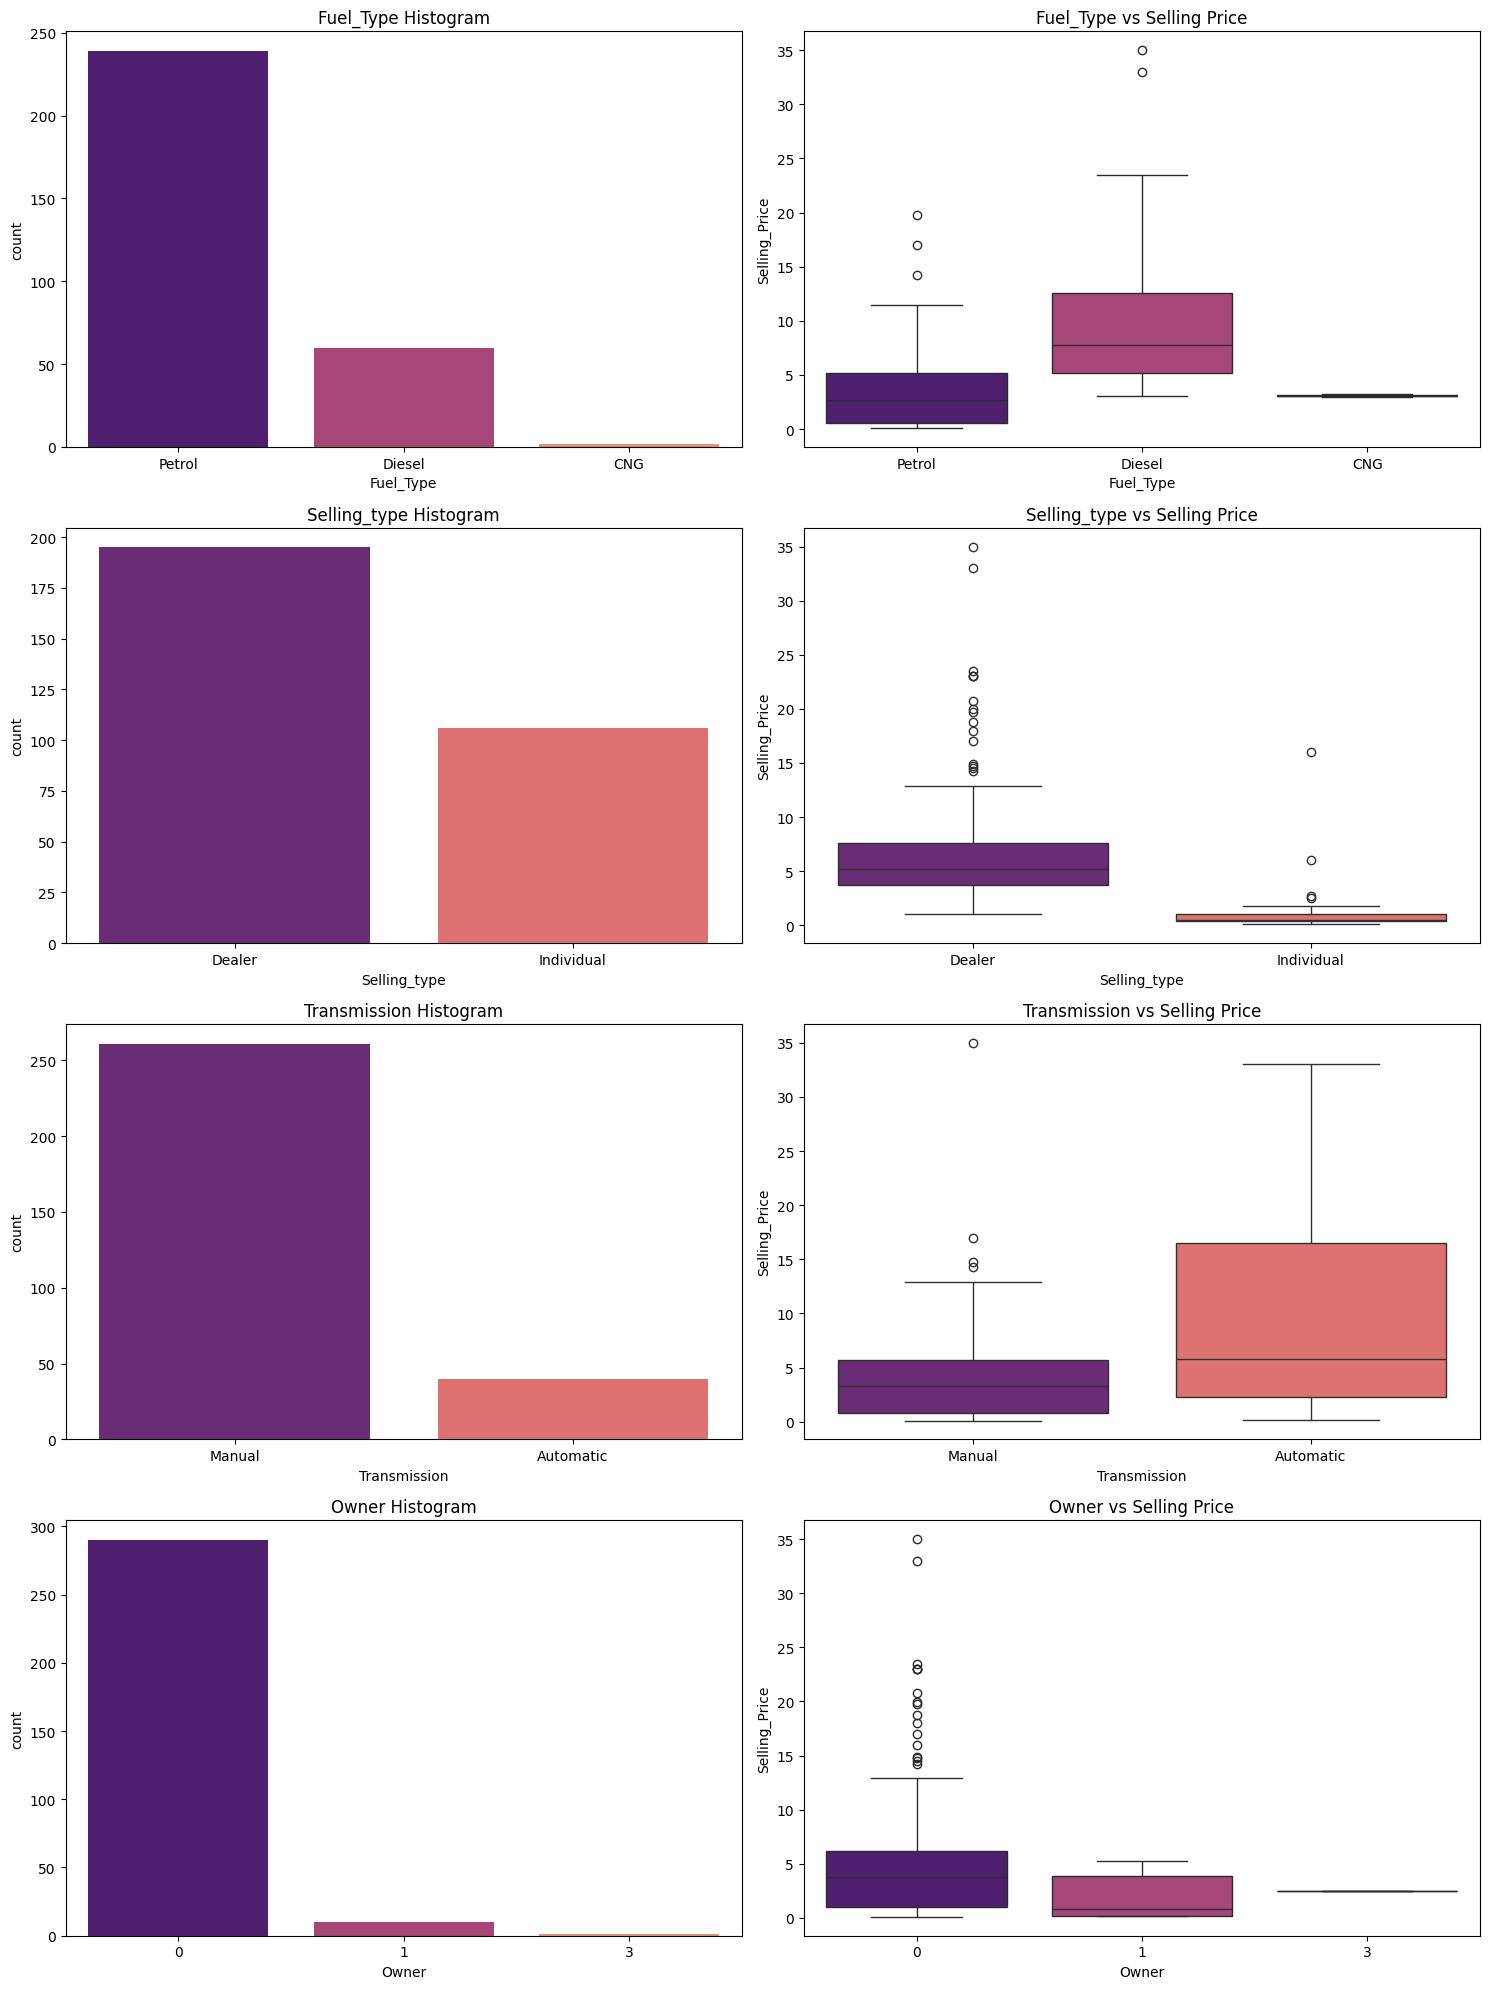

In [11]:
def plot_count(x, fig):
    plt.subplot(4, 2, fig)
    plt.title(x + ' Histogram')
    sns.countplot(x=x, data=df, palette="magma")

    plt.subplot(4, 2, (fig + 1))
    plt.title(x + ' vs Selling Price')
    sns.boxplot(x=x, y='Selling_Price', data=df, palette="magma")

plt.figure(figsize=(15, 20))
plot_count('Fuel_Type', 1)
plot_count('Selling_type', 3)
plot_count('Transmission', 5)
plot_count('Owner', 7)

plt.tight_layout()
plt.show()

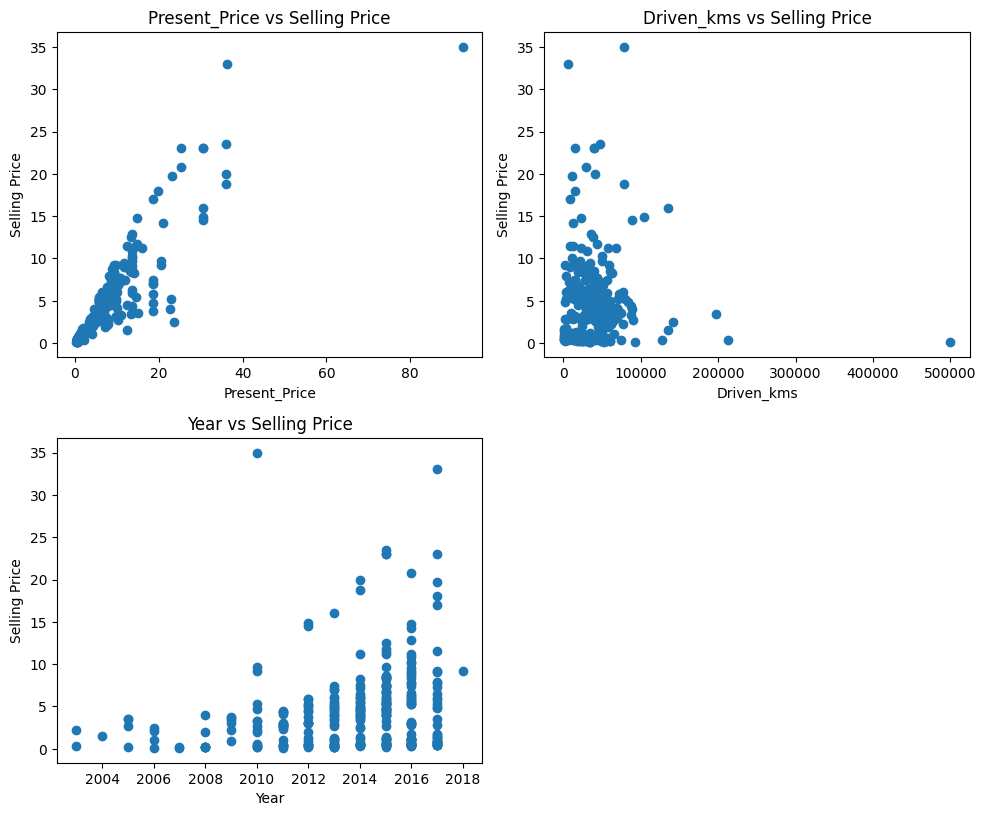

In [12]:
def scatter(x, fig):
    plt.subplot(5, 2, fig)
    plt.scatter(df[x], df['Selling_Price'])
    plt.title(x + ' vs Selling Price')
    plt.ylabel('Selling Price')
    plt.xlabel(x)

# Initialize the figure size
plt.figure(figsize=(10, 20))

# Using actual numerical columns present in 'car data.csv'
scatter('Present_Price', 1)
scatter('Driven_kms', 2)
scatter('Year', 3)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

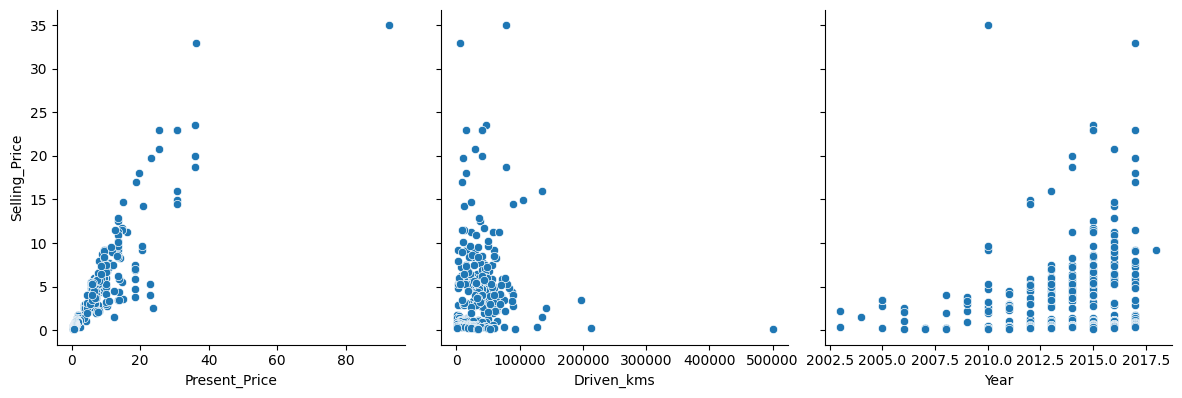

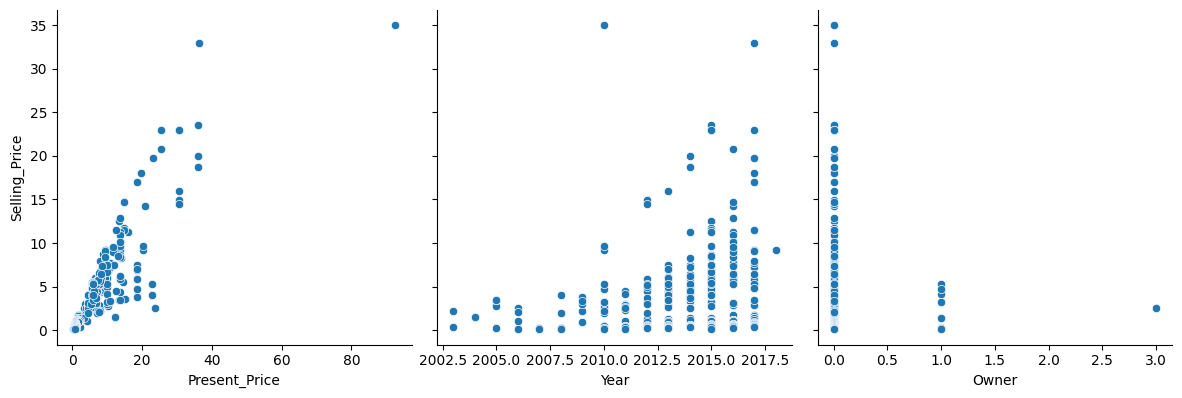

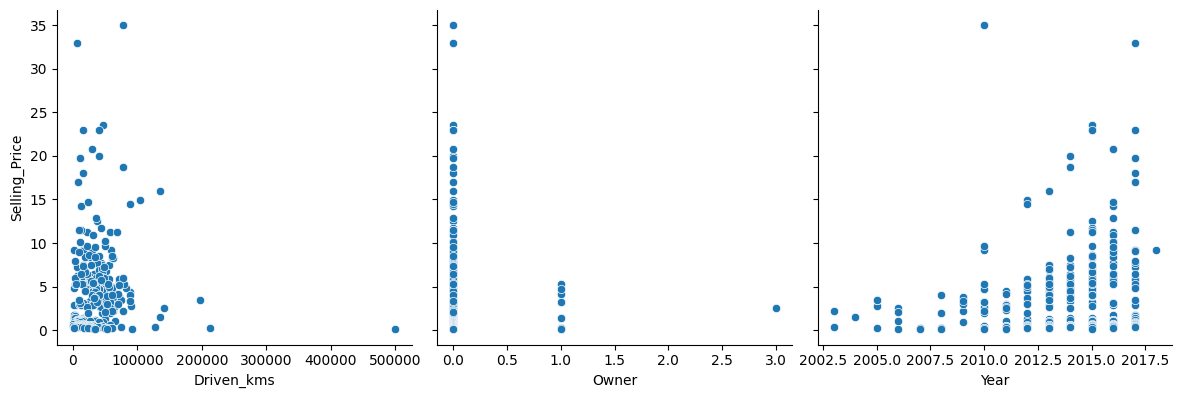

In [13]:
def pp(x, y, z):
    sns.pairplot(df, x_vars=[x, y, z], y_vars='Selling_Price', height=4, aspect=1, kind='scatter')
    plt.show()
pp('Present_Price', 'Driven_kms', 'Year')
pp('Present_Price', 'Year', 'Owner')
pp('Driven_kms', 'Owner', 'Year')

In [14]:
correlation = np.corrcoef(df['Present_Price'], df['Selling_Price'])[0, 1]

print(f"Correlation: {correlation}")

Correlation: 0.8789144098187831


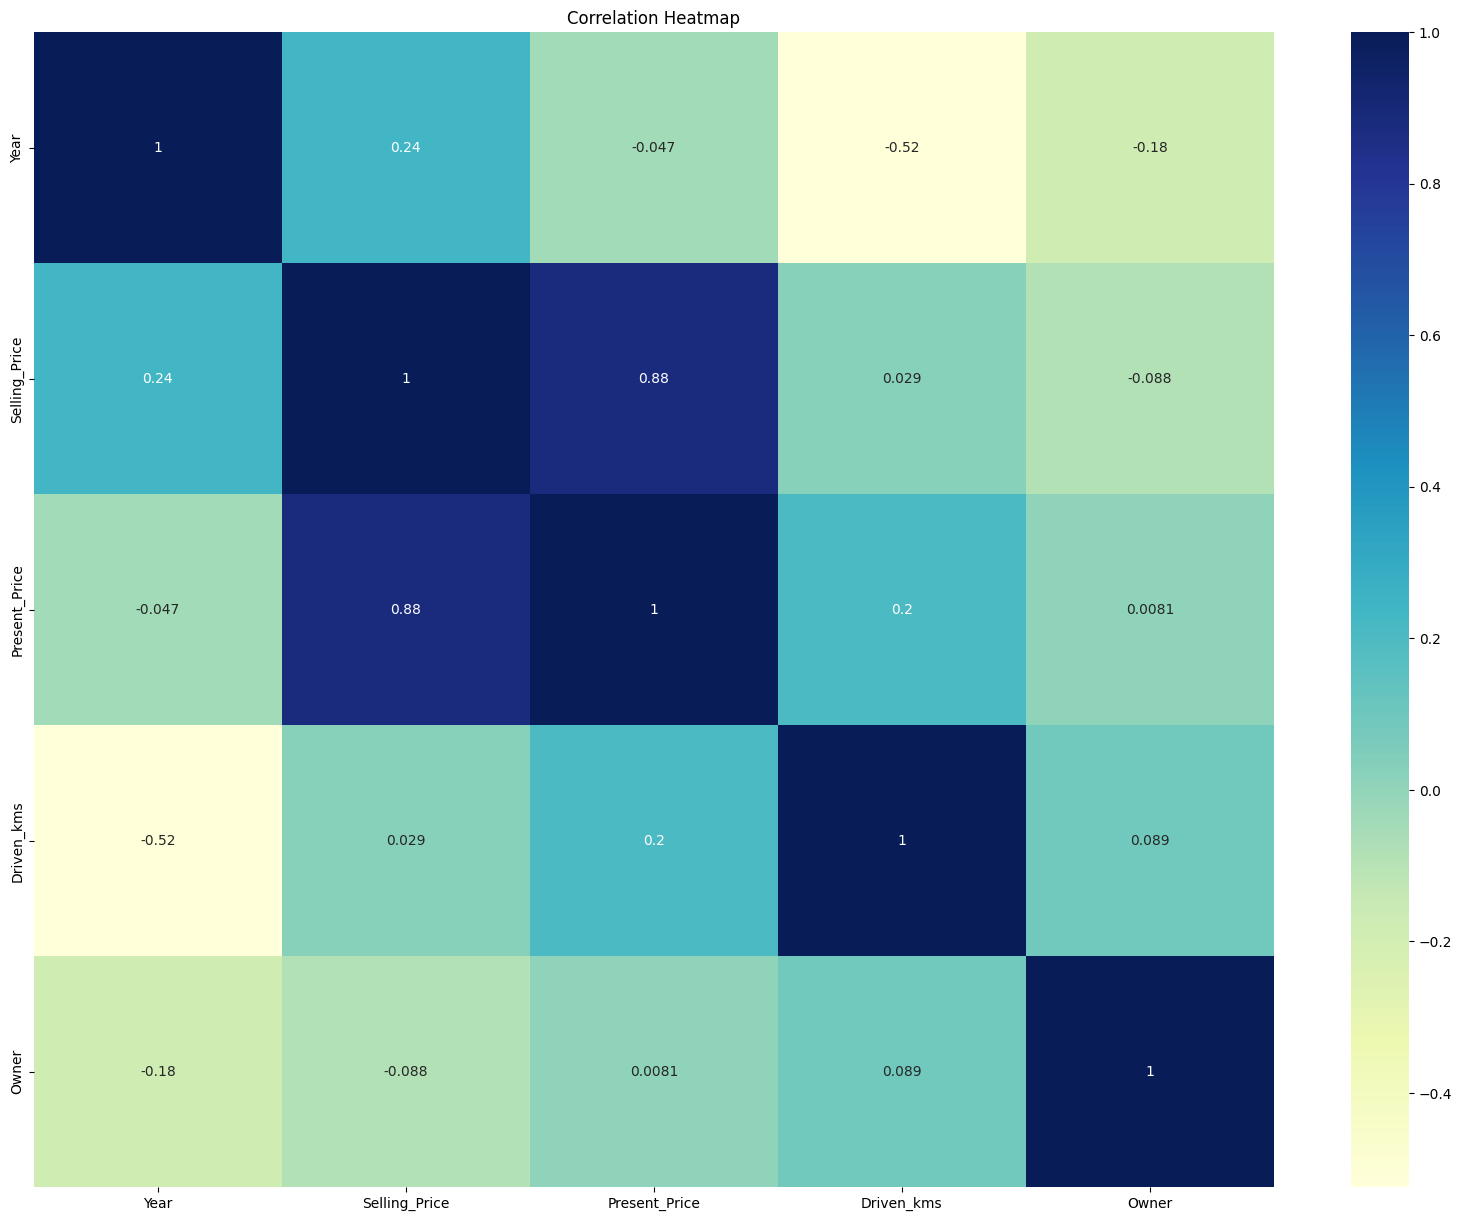

In [15]:
numeric_df = df.select_dtypes(include=[np.number])

# Plotting the heatmap
plt.figure(figsize=(20, 15))

sns.heatmap(numeric_df.corr(), cmap='YlGnBu', annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [16]:
df.columns

Index(['Year', 'Selling_Price', 'CompanyName', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [17]:
predict = 'Selling_Price'
data = df[["Year", "Present_Price", "Driven_kms", "Owner", "Selling_Price"]]
x = np.array(data.drop(predict, axis=1))
y = np.array(data[predict])

# Check the results
print("Features (x) shape:", x.shape)
print("Target (y) shape:", y.shape)

Features (x) shape: (301, 4)
Target (y) shape: (301,)


In [18]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2)
model = DecisionTreeRegressor()
model.fit(xtrain,ytrain)
predictions = model.predict(xtest)
model.score(xtest,predictions)

1.0